## Parte I — 05. Normalização e Standardization

**Unidade Curricular:** Laboratório de Análise de Dados  
**Dataset:** NBA Stats (1947–2026)  

---

### Objetivos deste Notebook

Preparar o dataset para os modelos de Machine Learning da Parte II através de normalização e estandardização. Algoritmos como KNN, SVM e Redes Neuronais são sensíveis à escala das variáveis — sem esta etapa, uma variável como `height_cm` (160–231) domina completamente uma como `fg_percent` (0–1), distorcendo os resultados.

1. Porquê normalizar — demonstrar visualmente a diferença de escalas  
2. Normalização Min-Max — transformar para o intervalo [0, 1]  
3. Estandardização Z-Score — transformar para média=0 e std=1  
4. Comparação visual — as três versões lado a lado  
5. Análise das novas distribuições — verificação estatística  
6. Guardar datasets normalizados — para uso na Parte II  
7. Análise crítica** — quando usar cada método  

---
## Imports e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

OUTPUT_DIR = './outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f8f8',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
})
PALETTE = ['#C9082A', '#1D428A', '#FFC72C', '#007A33', '#552583']

In [2]:
# Carregar datasets
enriched_path = f'{OUTPUT_DIR}dataset_nba_enriched.csv'
base_path = f'{OUTPUT_DIR}dataset_nba.csv'

if os.path.exists(enriched_path):
    df = pd.read_csv(enriched_path, low_memory=False)
    print('Dataset enriquecido carregado')
else:
    df = pd.read_csv(base_path, low_memory=False)
    print('Dataset base carregado')

# Filtro mínimo de 10 jogos
df = df[df['g'] >= 10].copy()

# Colunas numéricas a normalizar
COLS_NORM = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game',
             'blk_per_game', 'mp_per_game', 'fg_percent', 'ft_percent',
             'ts_percent', 'x3pa_per_game', 'per', 'ws', 'bpm', 'vorp',
             'height_cm', 'weight_kg', 'age']

COLS_NORM = [c for c in COLS_NORM if c in df.columns]

print(f'Dimensão : {df.shape[0]:,} registos × {df.shape[1]} colunas')
print(f'Colunas a normalizar: {len(COLS_NORM)}')

Dataset enriquecido carregado
Dimensão : 28,586 registos × 111 colunas
Colunas a normalizar: 17


---
## Porquê Normalizar?

Antes de normalizar, mostramos que as variáveis têm escalas completamente diferentes. Um algoritmo como o KNN calcula distâncias entre observações — se `height_cm` varia entre 160 e 231 e `fg_percent` varia entre 0 e 1, a altura vai dominar o cálculo de distâncias e a percentagem de campo vai ser ignorada.

In [3]:
# Tabela de escalas antes da normalização
escala = pd.DataFrame({
    'Mínimo': df[COLS_NORM].min(),
    'Máximo': df[COLS_NORM].max(),
    'Média': df[COLS_NORM].mean(),
    'Std': df[COLS_NORM].std(),
    'Range': df[COLS_NORM].max() - df[COLS_NORM].min(),
}).round(3)

print('Escalas das variáveis antes da normalização:\n')
escala.style \
    .background_gradient(cmap='YlOrRd', subset=['Range']) \
    .format(precision=3) \
    .set_caption('Quanto maior o Range, mais dominante a variável sem normalização')

Escalas das variáveis antes da normalização:



,Mínimo,Máximo,Média,Std,Range
pts_per_game,0.000,50.400,8.855,5.990,50.400
ast_per_game,0.000,14.500,2.010,1.796,14.500
trb_per_game,0.000,27.200,3.882,2.732,27.200
stl_per_game,0.000,3.700,0.696,0.454,3.700
blk_per_game,0.000,5.600,0.426,0.488,5.600
mp_per_game,1.800,48.500,21.151,9.604,46.700
fg_percent,0.000,1.000,0.442,0.070,1.000
ft_percent,0.000,1.000,0.729,0.123,1.000
ts_percent,0.000,0.868,0.511,0.069,0.868
x3pa_per_game,0.000,13.200,1.574,1.851,13.200


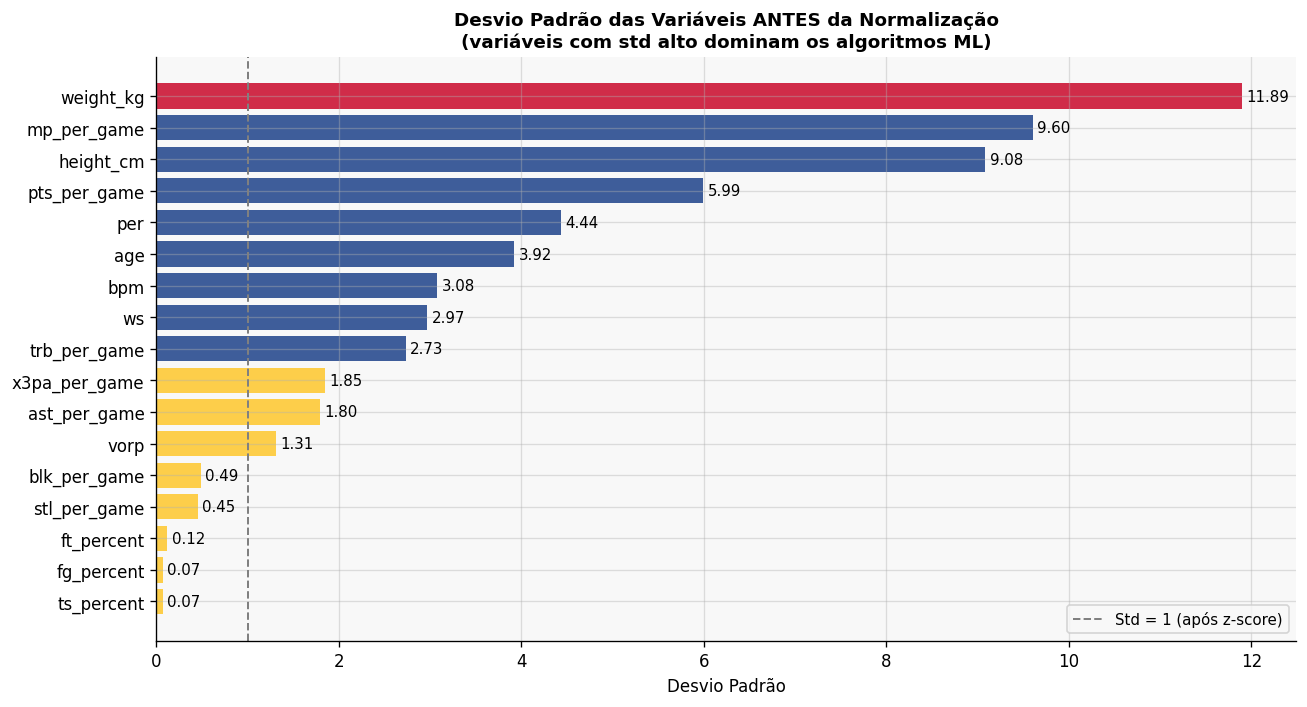

In [4]:
# Gráfico — desvio padrão de cada variável antes de normalizar

stds = df[COLS_NORM].std().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [PALETTE[0] if v > 10 else PALETTE[1] if v > 2 else PALETTE[2] for v in stds.values]
bars = ax.barh(stds.index, stds.values, color=colors, alpha=0.85)

for bar, val in zip(bars, stds.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.2, label='Std = 1 (após z-score)')
ax.set_title('Desvio Padrão das Variáveis ANTES da Normalização\n'
             '(variáveis com std alto dominam os algoritmos ML)', fontweight='bold', fontsize=11)
ax.set_xlabel('Desvio Padrão')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_sec1_escalas_originais.png', bbox_inches='tight')
plt.show()

---
## Normalização Min-Max

A normalização Min-Max transforma cada variável para o intervalo [0, 1] usando a fórmula:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

O valor mínimo passa a 0 e o valor máximo passa a 1. A forma da distribuição é preservada — apenas a escala muda. A desvantagem é que é sensível a outliers extremos, que comprimem os restantes valores.

In [5]:
# Aplicar normalização Min-Max manualmente

df_minmax = df.copy()

for col in COLS_NORM:
    col_min = df[col].min()
    col_max = df[col].max()
    rng = col_max - col_min
    if rng > 0:
        df_minmax[col] = ((df[col] - col_min) / rng).round(4)
    else:
        df_minmax[col] = 0.0  

# Verificação rápida
print('Verificação Min-Max:')
for col in COLS_NORM[:5]:
    print(f'  {col} min={df_minmax[col].min():.3f}  max={df_minmax[col].max():.3f}')

Verificação Min-Max:
  pts_per_game min=0.000  max=1.000
  ast_per_game min=0.000  max=1.000
  trb_per_game min=0.000  max=1.000
  stl_per_game min=0.000  max=1.000
  blk_per_game min=0.000  max=1.000


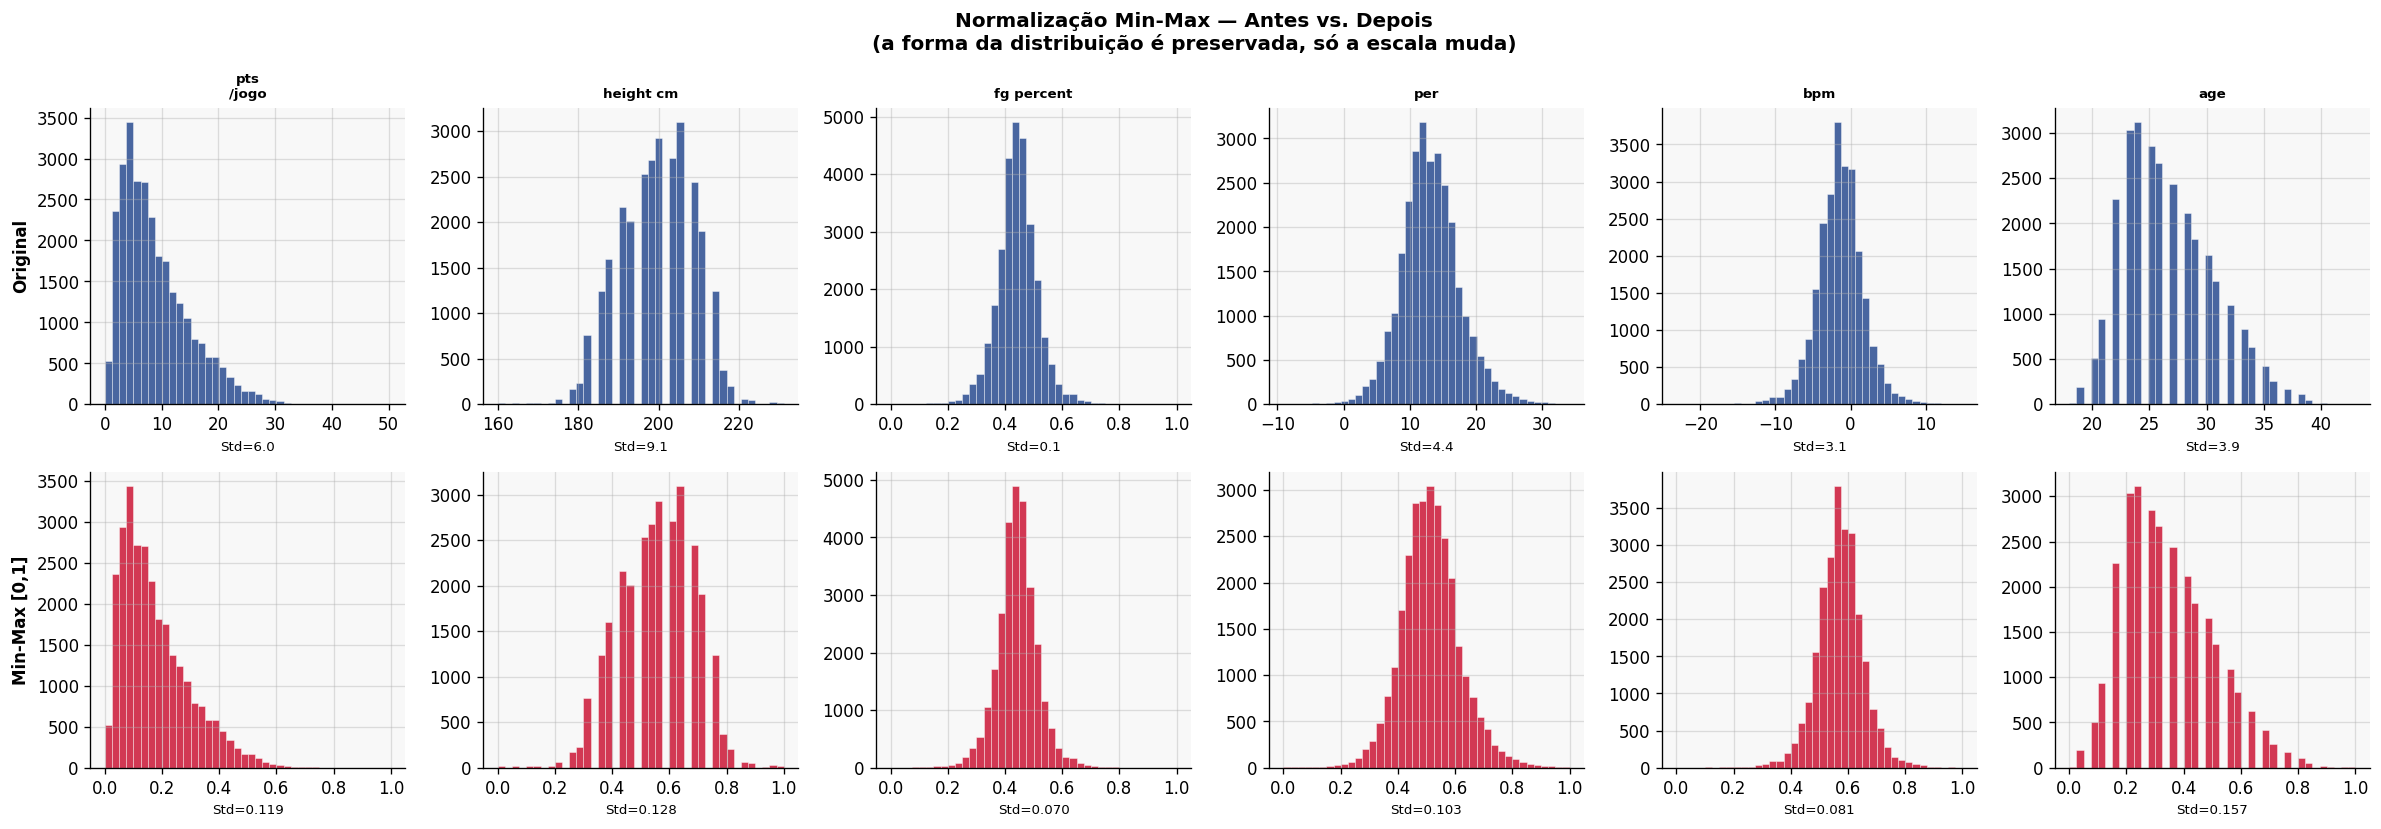

Gráfico guardado.


In [6]:
# Histogramas — antes vs. depois da normalização Min-Max
# Escolher 6 variáveis representativas com escalas muito diferentes

cols_demo = ['pts_per_game', 'height_cm', 'fg_percent', 'per', 'bpm', 'age']

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, col in enumerate(cols_demo):
    # Linha de cima — original
    axes[0, i].hist(df[col].dropna(), bins=40, color=PALETTE[1], alpha=0.8,
                    edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(col.replace('_per_game','\n/jogo').replace('_',' '),
                         fontsize=8, fontweight='bold')
    axes[0, i].set_xlabel(f"Std={df[col].std():.1f}", fontsize=8)

    # Linha de baixo — normalizado
    axes[1, i].hist(df_minmax[col].dropna(), bins=40, color=PALETTE[0], alpha=0.8,
                    edgecolor='white', linewidth=0.3)
    axes[1, i].set_xlabel('Std={:.3f}'.format(df_minmax[col].std()), fontsize=8)

axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Min-Max [0,1]', fontsize=10, fontweight='bold')

plt.suptitle('Normalização Min-Max — Antes vs. Depois\n'
             '(a forma da distribuição é preservada, só a escala muda)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_sec2_minmax.png', bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

---
## Standardization Z-Score

A Standardization Z-Score transforma cada variável para ter média 0 e desvio padrão 1 usando a fórmula:

$$x_{std} = \frac{x - \mu}{\sigma}$$

É o método preferido para a maioria dos algoritmos ML porque é mais robusto a outliers do que o Min-Max — um valor extremo não comprime todos os outros para perto de 0 ou 1.

In [7]:
# Aplicar Standardization Z-Score manualmente

df_zscore = df.copy()

for col in COLS_NORM:
    media = df[col].mean()
    std   = df[col].std()
    if std > 0:
        df_zscore[col] = ((df[col] - media) / std).round(4)
    else:
        df_zscore[col] = 0.0

# Verificação rápida
print('Verificação Z-Score:')
for col in COLS_NORM[:5]:
    print(f'  {col} média={df_zscore[col].mean():.4f}  std={df_zscore[col].std():.4f}')

Verificação Z-Score:
  pts_per_game média=-0.0000  std=1.0000
  ast_per_game média=-0.0000  std=1.0000
  trb_per_game média=-0.0000  std=1.0000
  stl_per_game média=-0.0000  std=1.0000
  blk_per_game média=0.0000  std=1.0000


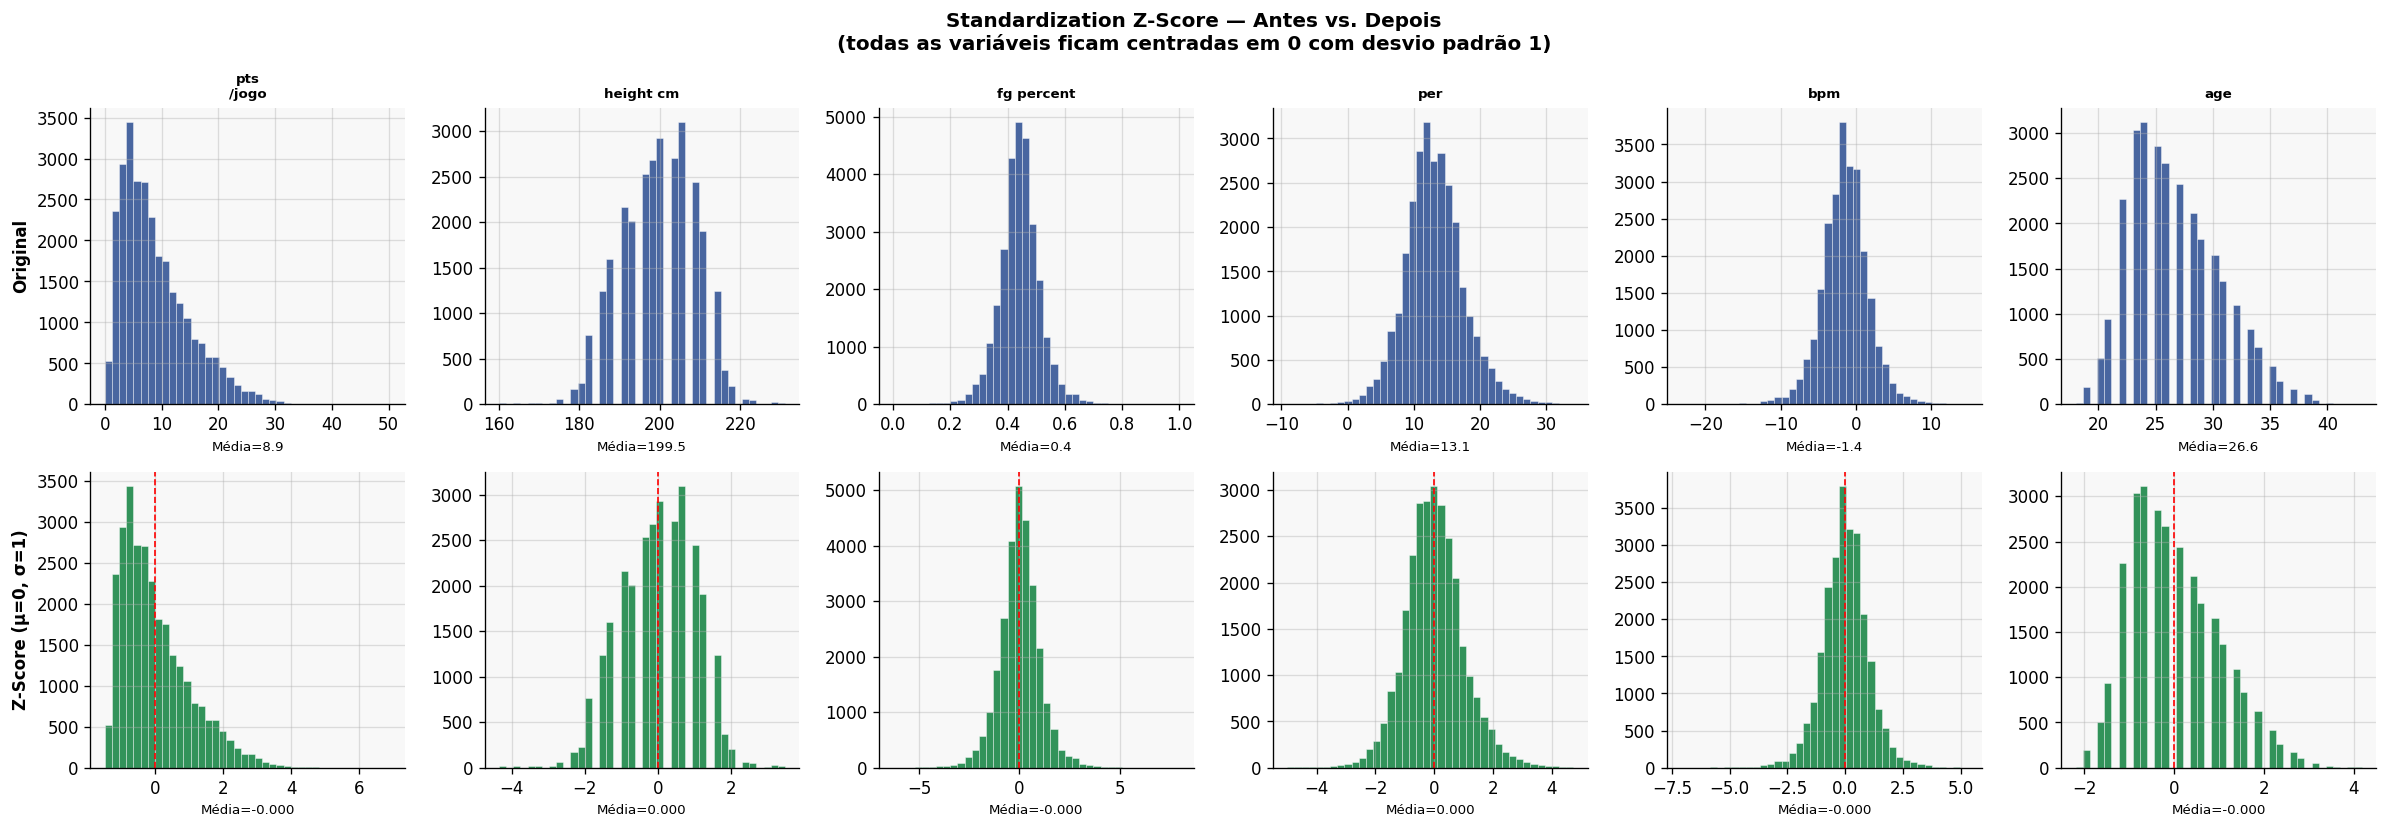

In [8]:
# Histogramas — antes vs. depois da Standardization Z-Score

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i, col in enumerate(cols_demo):
    axes[0, i].hist(df[col].dropna(), bins=40, color=PALETTE[1], alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(col.replace('_per_game','\n/jogo').replace('_',' '), fontsize=8, fontweight='bold')
    axes[0, i].set_xlabel(f"Média={df[col].mean():.1f}", fontsize=8)

    axes[1, i].hist(df_zscore[col].dropna(), bins=40, color=PALETTE[3], alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[1, i].set_xlabel('Média={:.3f}'.format(df_zscore[col].mean()), fontsize=8)
    axes[1, i].axvline(x=0, color='red', linewidth=1, linestyle='--')

axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Z-Score (μ=0, σ=1)', fontsize=10, fontweight='bold')

plt.suptitle('Standardization Z-Score — Antes vs. Depois\n'
             '(todas as variáveis ficam centradas em 0 com desvio padrão 1)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_sec3_zscore.png', bbox_inches='tight')
plt.show()

---
## Comparação Visual

As três versões lado a lado (original, Min-Max, Z-Score) para as mesmas variáveis. Permite perceber intuitivamente o que cada transformação faz à distribuição.

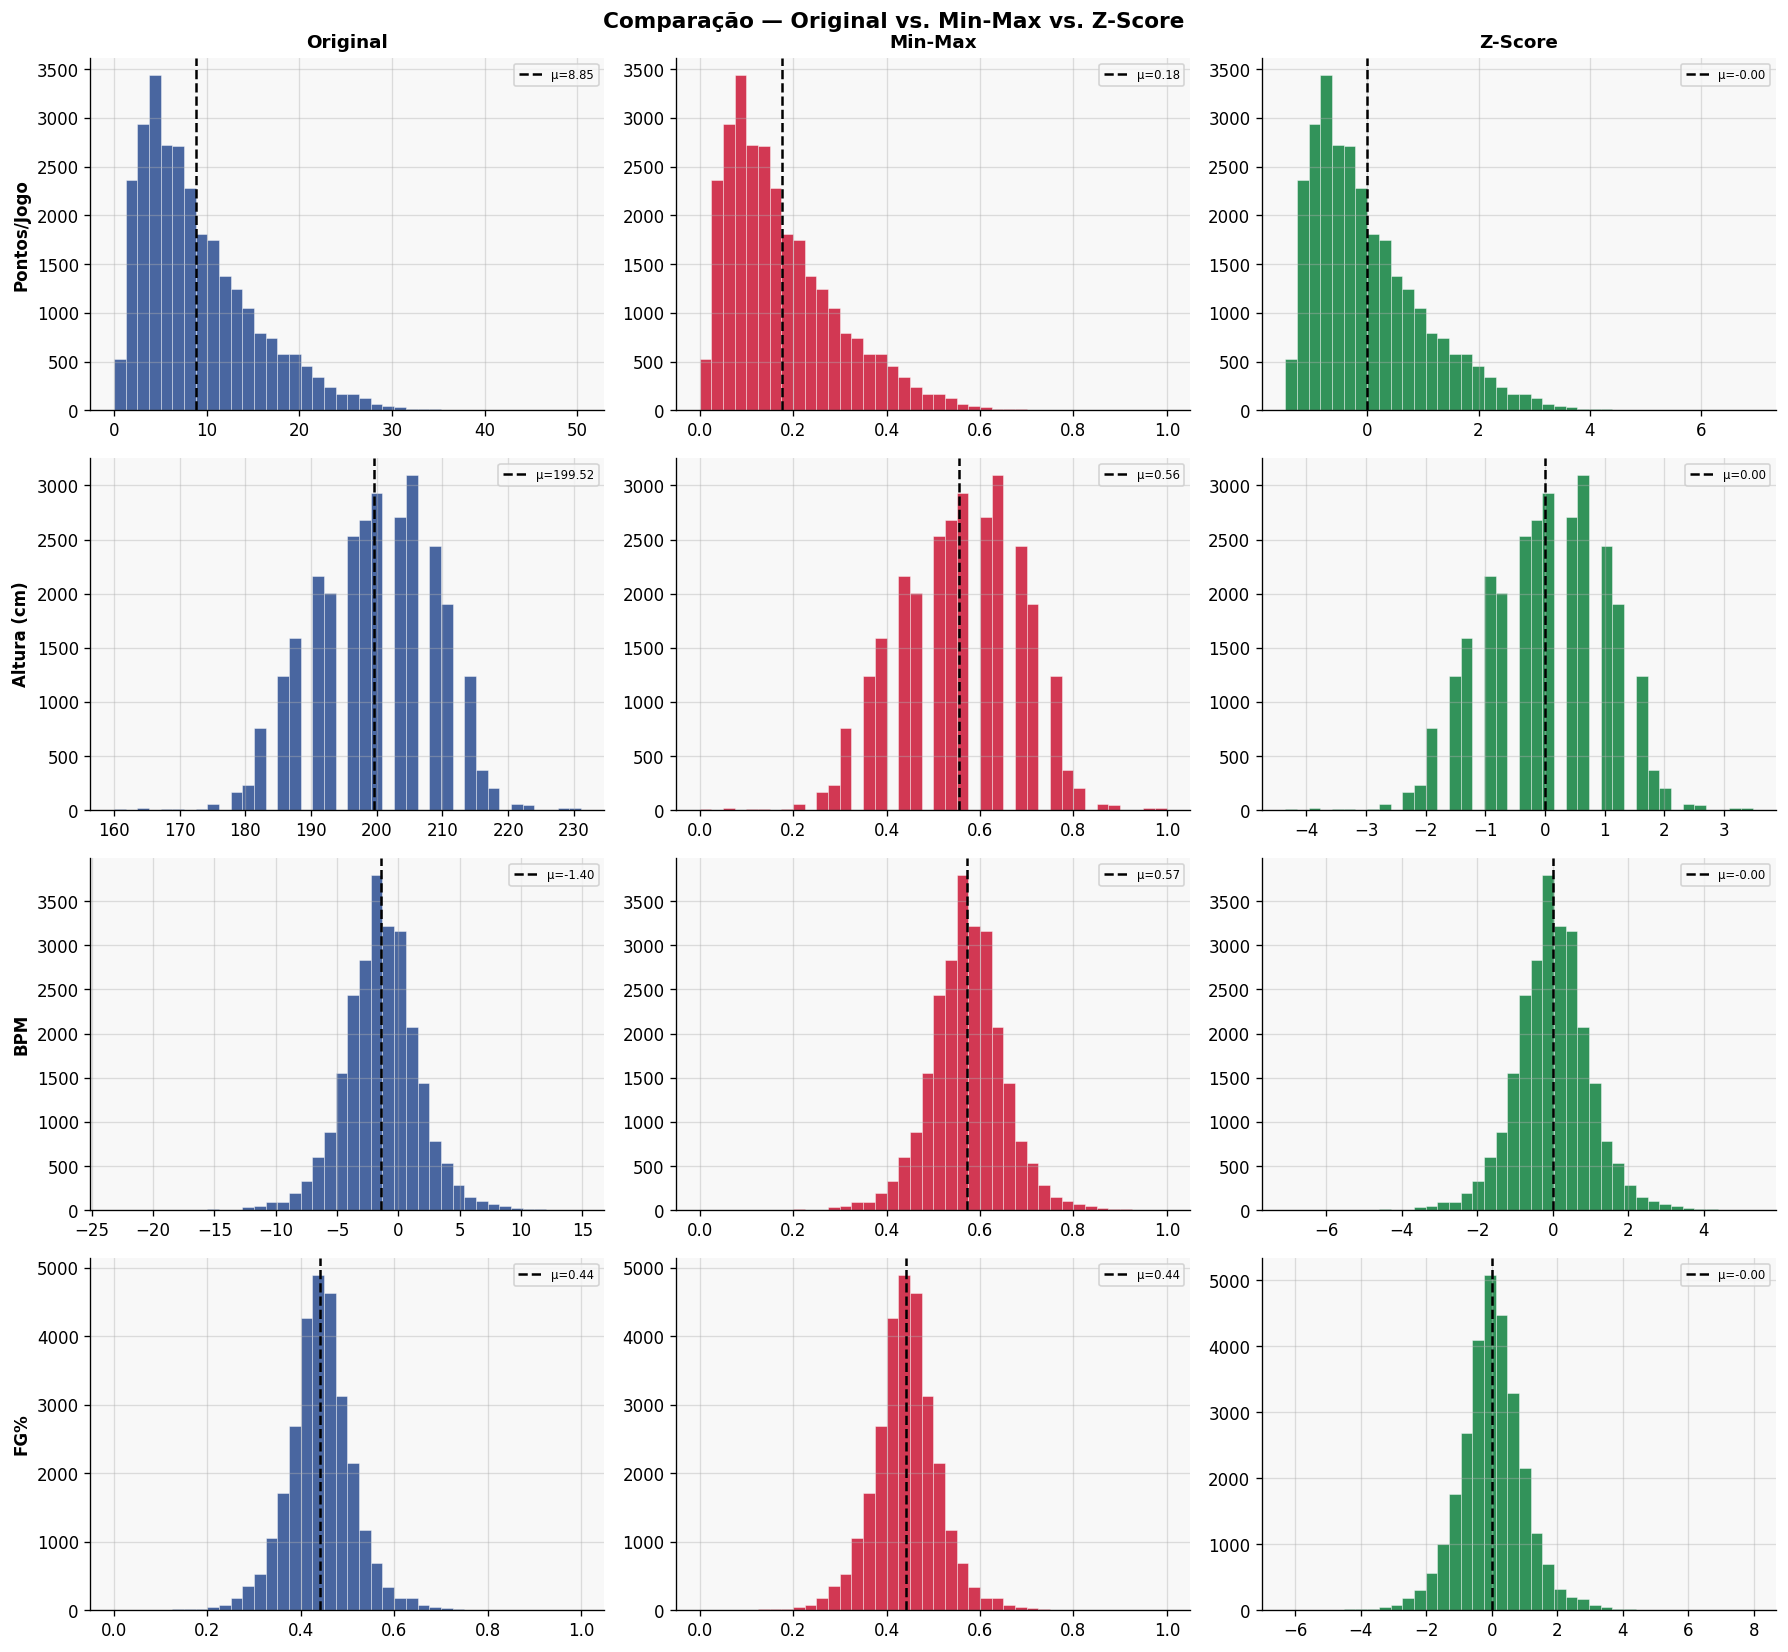

In [9]:
cols_cmp = ['pts_per_game', 'height_cm', 'bpm', 'fg_percent']
titulos  = ['Pontos/Jogo', 'Altura (cm)', 'BPM', 'FG%']
versoes  = [
    (df, 'Original', PALETTE[1]),
    (df_minmax, 'Min-Max', PALETTE[0]),
    (df_zscore, 'Z-Score', PALETTE[3]),
]

fig, axes = plt.subplots(len(cols_cmp), 3, figsize=(15, 14))

for i, (col, titulo) in enumerate(zip(cols_cmp, titulos)):
    for j, (dataset, label, color) in enumerate(versoes):
        ax = axes[i, j]
        data = dataset[col].dropna()
        ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
        ax.axvline(data.mean(), color='black', linewidth=1.5, linestyle='--', label=f'μ={data.mean():.2f}')
        ax.legend(fontsize=7)

        if i == 0:
            ax.set_title(label, fontweight='bold', fontsize=11)
        if j == 0:
            ax.set_ylabel(titulo, fontweight='bold', fontsize=10)

plt.suptitle('Comparação — Original vs. Min-Max vs. Z-Score', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_sec4_comparacao.png', bbox_inches='tight')
plt.show()

---
## Análise das Novas Distribuições

- Min-Max: todos os valores entre 0 e 1  
- Z-Score: média ≈ 0 e desvio padrão ≈ 1 para todas as colunas

In [10]:
# Estatísticas após cada normalização

confirmacao = pd.DataFrame(index=COLS_NORM)

confirmacao['Original — Média'] = df[COLS_NORM].mean().round(3)
confirmacao['Original — Std'] = df[COLS_NORM].std().round(3)
confirmacao['MinMax — Min'] = df_minmax[COLS_NORM].min().round(4)
confirmacao['MinMax — Max'] = df_minmax[COLS_NORM].max().round(4)
confirmacao['ZScore — Média'] = df_zscore[COLS_NORM].mean().round(4)
confirmacao['ZScore — Std'] = df_zscore[COLS_NORM].std().round(4)

def highlight_ok(val):
    #Verde se o valor está dentro do esperado.
    return 'background-color: #d4edda' if isinstance(val, float) else ''

print('Tabela de confirmação das normalizações:\n')
confirmacao.style \
    .format(precision=4) \
    .set_caption('Min-Max: min=0.0, max=1.0 | Z-Score: média≈0, std≈1')

Tabela de confirmação das normalizações:



,Original — Média,Original — Std,MinMax — Min,MinMax — Max,ZScore — Média,ZScore — Std
pts_per_game,8.8550,5.9900,0.0000,1.0000,-0.0000,1.0000
ast_per_game,2.0100,1.7960,0.0000,1.0000,-0.0000,1.0000
trb_per_game,3.8820,2.7320,0.0000,1.0000,-0.0000,1.0000
stl_per_game,0.6960,0.4540,0.0000,1.0000,-0.0000,1.0000
blk_per_game,0.4260,0.4880,0.0000,1.0000,0.0000,1.0000
mp_per_game,21.1510,9.6040,0.0000,1.0000,-0.0000,1.0000
fg_percent,0.4420,0.0700,0.0000,1.0000,-0.0000,1.0000
ft_percent,0.7290,0.1230,0.0000,1.0000,-0.0000,1.0000
ts_percent,0.5110,0.0690,0.0000,1.0000,0.0000,1.0000
x3pa_per_game,1.5740,1.8510,0.0000,1.0000,0.0000,1.0000


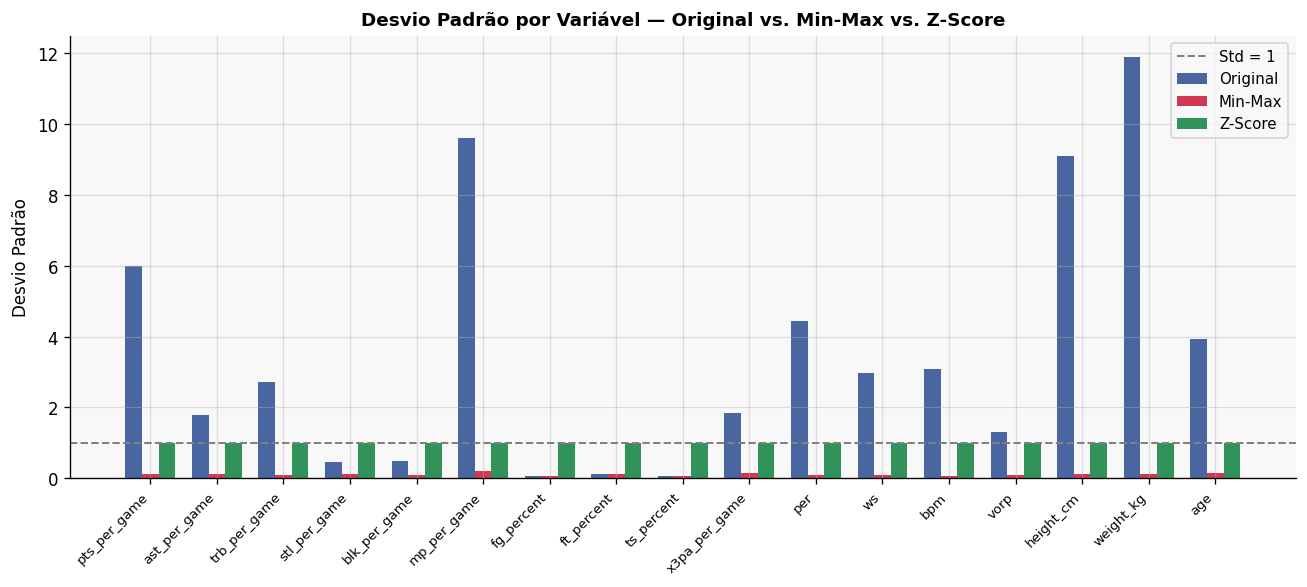

In [11]:
# Boxplot comparativo — desvios padrão antes e depois

stds_orig   = df[COLS_NORM].std()
stds_minmax = df_minmax[COLS_NORM].std()
stds_zscore = df_zscore[COLS_NORM].std()

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(COLS_NORM))
w = 0.25

ax.bar(x - w, stds_orig.values, w, label='Original', color=PALETTE[1], alpha=0.8)
ax.bar(x, stds_minmax.values, w, label='Min-Max', color=PALETTE[0], alpha=0.8)
ax.bar(x + w, stds_zscore.values, w, label='Z-Score', color=PALETTE[3], alpha=0.8)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=1.2, label='Std = 1')
ax.set_xticks(x)
ax.set_xticklabels(COLS_NORM, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Desvio Padrão')
ax.set_title('Desvio Padrão por Variável — Original vs. Min-Max vs. Z-Score', fontweight='bold', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_sec5_std_comparacao.png', bbox_inches='tight')
plt.show()

---
## Guardar Datasets Normalizados

Exportar os dois datasets transformados para uso na Parte II. As colunas não numéricas (player, season, team, etc.) são mantidas sem alteração — só as colunas em `COLS_NORM` são transformadas.

In [12]:
# Guardar os dois datasets normalizados

path_minmax = f'{OUTPUT_DIR}dataset_minmax.csv'
path_zscore = f'{OUTPUT_DIR}dataset_zscore.csv'

df_minmax.to_csv(path_minmax, index=False)
df_zscore.to_csv(path_zscore, index=False)

print('Datasets guardados:')
print(f'  Min-Max : {path_minmax}')
print(f'            {df_minmax.shape[0]:,} linhas × {df_minmax.shape[1]} colunas')
print(f'            {os.path.getsize(path_minmax)/1024/1024:.1f} MB')
print()
print(f'  Z-Score : {path_zscore}')
print(f'            {df_zscore.shape[0]:,} linhas × {df_zscore.shape[1]} colunas')
print(f'            {os.path.getsize(path_zscore)/1024/1024:.1f} MB')

Datasets guardados:
  Min-Max : ./outputs/dataset_minmax.csv
            28,586 linhas × 111 colunas
            13.9 MB

  Z-Score : ./outputs/dataset_zscore.csv
            28,586 linhas × 111 colunas
            14.3 MB


---
## Análise Crítica

### Quando usar cada método?

---

Normalização Min-Max é preferível quando:
- O algoritmo precisa de valores num intervalo fixo 
- A distribuição dos dados não é gaussiana
- Não existem outliers extremos — o Min-Max é muito sensível a outliers porque um único valor extremo comprime todos os restantes para perto de 0 ou 1

Standardization Z-Score é preferível quando:
- O algoritmo assume distribuição normal (ex: Regressão Logística, SVM, KNN)
- Existem outliers — o Z-Score é mais robusto porque usa média e desvio padrão, que são menos afectados por valores extremos do que o mínimo e o máximo
- É o método mais comum em Machine Learning em geral

No contexto deste dataset, o Z-Score é a escolha mais adequada para a Parte II porque:
1. Os dados de basquetebol têm outliers naturais — Wilt Chamberlain com 50 pontos por jogo, por exemplo
2. Os modelos que vamos usar (Regressão Logística, Random Forest, KNN) beneficiam da standardization
3. A interpretabilidade mantém-se — um z-score de 2.0 significa que o jogador está 2 desvios padrão acima da média da liga

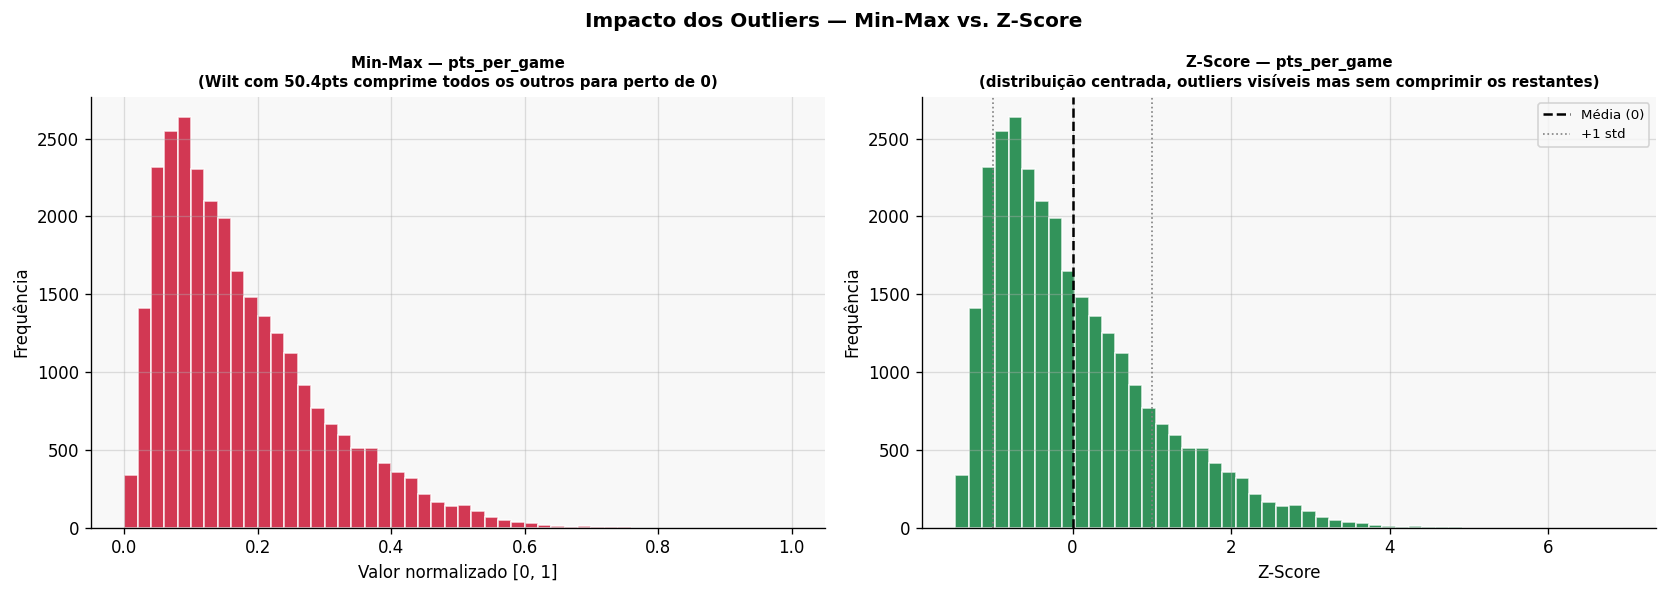

In [13]:
# Demonstração do problema dos outliers com Min-Max

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Min-Max — efeito do outlier
axes[0].hist(df_minmax['pts_per_game'].dropna(), bins=50, color=PALETTE[0], alpha=0.8, edgecolor='white')
axes[0].set_title('Min-Max — pts_per_game\n'
                  '(Wilt com 50.4pts comprime todos os outros para perto de 0)', fontweight='bold', fontsize=9)
axes[0].set_xlabel('Valor normalizado [0, 1]')
axes[0].set_ylabel('Frequência')

# Z-Score — mais robusto
axes[1].hist(df_zscore['pts_per_game'].dropna(), bins=50, color=PALETTE[3], alpha=0.8, edgecolor='white')
axes[1].axvline(x=0,  color='black', linewidth=1.5, linestyle='--', label='Média (0)')
axes[1].axvline(x=1,  color='gray',  linewidth=1,   linestyle=':',  label='+1 std')
axes[1].axvline(x=-1, color='gray',  linewidth=1,   linestyle=':')
axes[1].set_title('Z-Score — pts_per_game\n'
                  '(distribuição centrada, outliers visíveis mas sem comprimir os restantes)', fontweight='bold', fontsize=9)
axes[1].set_xlabel('Z-Score')
axes[1].set_ylabel('Frequência')
axes[1].legend(fontsize=8)

plt.suptitle('Impacto dos Outliers — Min-Max vs. Z-Score', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_sec7_outliers.png', bbox_inches='tight')
plt.show()